# <b><font color='lightcoral'>Переобучение и недообучение</font></b>

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import accuracy_score

### <b><font color='lightcoral'>1. Диагностика переобучения и недообучения</font></b>

##### <b><font color='lightcoral'>1.1. Кривые обучения</font></b>

In [35]:
# Загрузите набор данных fetch_california_housing в переменную data
data = fetch_california_housing(as_frame=True)
data.frame

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [3]:
# Определите переменные независимые (X) и зависимые (y)
X, y = data.data, data.target

In [4]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [5]:
# Определите функцию для построения кривых обучения
# estimator - любая модель sklearn
# X, y - данные и целевая переменная
# train_sizes - какие доли данных будем использовать (по умолчанию от 10% до 100%)
# cv = 5 - будем использовать 5-fold cross-validation

def plot_learning_curves(estimator, X, y, train_sizes = np.linspace(0.1, 1.0, 10), cv = 5):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator, X, y, train_sizes = train_sizes, cv = cv, scoring = 'neg_mean_squared_error'
    )
    
    train_scores_mean = -train_scores.mean(axis = 1)
    validation_scores_mean = -validation_scores.mean(axis = 1)
    
    plt.figure(figsize = (12, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color = 'r', label = 'Training error')
    plt.plot(train_sizes, validation_scores_mean, 'o-', color = 'g', label = 'Validation error')
    plt.xlabel('Размер обучающих данных')
    plt.ylabel('Ошибка')
    plt.title('Кривые обучения')
    plt.legend(loc = 'best')
    plt.grid()
    plt.show()

In [6]:
# Инициализируйте модель дерева решений
model = DecisionTreeRegressor(max_depth = 15, random_state = 42)

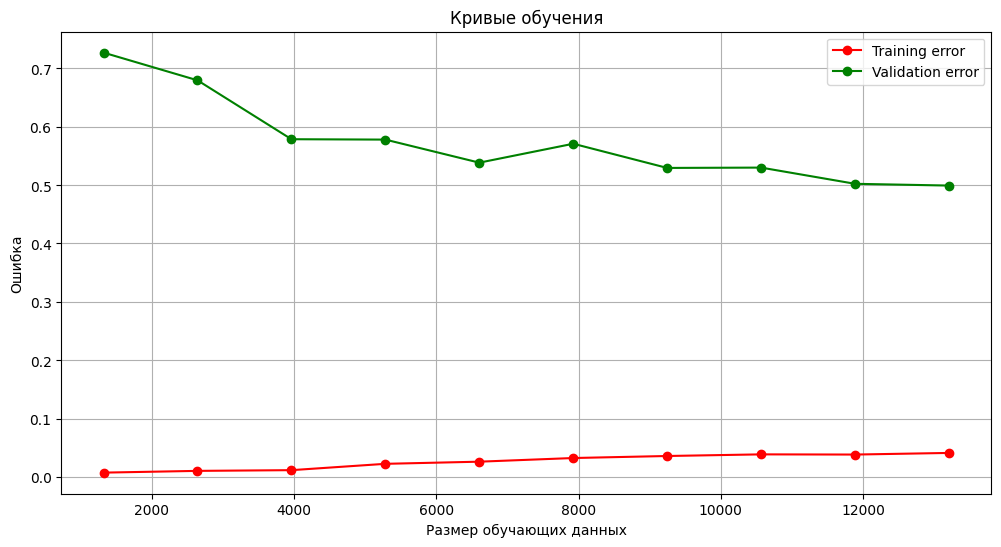

In [7]:
# Постройте кривые обучения
plot_learning_curves(model, X_train, y_train)

##### <b><font color='lightcoral'>1.2. Кросс-валидация</font></b>

In [8]:
from sklearn.datasets import load_breast_cancer

In [9]:
# Загрузите набор данных в переменную data и определите входные (X) и целевые (y) значения 
data = load_breast_cancer()
X, y = data.data, data.target

In [10]:
# Инициализируйте модель дерева решений в переменную model
model = DecisionTreeClassifier(random_state = 42)

In [11]:
# Выполните 5-кратную перекрестную валидацию в переменную cv_scores
cv_scores = cross_val_score(model, X, y, cv = 5, scoring = 'accuracy')

In [12]:
# Выведите оценки кросс-валидации
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Средняя оценка кросс-валидации: {cv_scores.mean()}')

Cross-Validation Scores: [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
Средняя оценка кросс-валидации: 0.9173420276354604


In [13]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [14]:
# Обучите модель на обучающих данных
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [15]:
# Сделайте предсказания на обучающем и тестовом наборах
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [16]:
# Рассчитайте accuracy на обучающем и тестовом наборах
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [17]:
print(f'Training Accuracy: {train_accuracy}')
print(f'Testing Accuracy: {test_accuracy}')

Training Accuracy: 1.0
Testing Accuracy: 0.9473684210526315


### <b><font color='lightcoral'>2. Регуляризация</font></b>

In [39]:
# Импорт дополнительных библиотек

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

##### <b><font color='lightcoral'>2.1. Подготовка данных</font></b>

In [40]:
# Загрузка набора данных
data = fetch_california_housing()
X, y = data.data, data.target

##### <b><font color='lightcoral'>2.2. Разделение на обучение и тестирование</font></b>

In [41]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### <b><font color='lightcoral'>2.3. Стандартизация данных</font></b>

In [42]:
# Стандартиазация данных - важно для задач регуляризации
scaler = StandardScaler()

In [43]:
# Подгонка и преобразование обучающих данных
X_train_scaled = scaler.fit_transform(X_train)

In [44]:
# Преобразование тестовых данных
X_test_scaled = scaler.transform(X_test)

##### <b><font color='lightcoral'>2.4. Обучение и оценка модели регрессии LASSO</font></b>

In [45]:
# Инициализируем регрессионную модель LASSO с параметром регуляризации alpha
lasso = Lasso(alpha=0.1)

In [46]:
# Обучите модель на обучающих данных
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [47]:
# Делаем прогнозы на тестовых данных
y_pred_lasso = lasso.predict(X_test_scaled)

In [48]:
# Оценить модель
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [49]:
print(f'Регрессия LASSO - средняя квадратичная ошибка: {mse_lasso}')
print(f'Регрессия LASSO - R-квадрат: {r2_lasso}')

Регрессия LASSO - средняя квадратичная ошибка: 0.6796290284328821
Регрессия LASSO - R-квадрат: 0.4813611325029077


##### <b><font color='lightcoral'>2.5. Обучение и оценка модели гребневой регрессии</font></b>

In [50]:
# Инициализируем модель ридж-регрессии с параметром регуляризации alpha
ridge = Ridge(alpha=0.1)

In [51]:
# Обучить модель на обучающих данных
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [52]:
# Делаем прогнозы на тестовых данных
y_pred_ridge = ridge.predict(X_test_scaled)

In [53]:
# Оценить модель
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Regression - Mean Squared Error: {mse_ridge}')
print(f'Ridge Regression - R-квадрат: {r2_ridge}')

Ridge Regression - Mean Squared Error: 0.555887913867418
Ridge Regression - R-квадрат: 0.5757905180002314


In [56]:
df_california = fetch_california_housing()
df_california
X = df_california.data
y = df_california.target
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X, y, test_size = 0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train_lin, y_train_lin)
y_pred_lin = model.predict(X_test_lin)
mse_lin = mean_squared_error(y_test_lin, y_pred_lin)
r2_lin = r2_score(y_test_lin, y_pred_lin)
print(f"Mean Squared Error: {mse_lin}")
print(f"R-squared: {r2_lin}")

Mean Squared Error: 0.5558915986952425
R-squared: 0.5757877060324521


##### <b><font color='lightcoral'>2.6. Сравнение результатов</font></b>

In [58]:
coefficients = pd.DataFrame({
    'Feature': data.feature_names,
    'Коэффициенты LASSO': lasso.coef_,
    'Ridge Coefficients': ridge.coef_,
    'Linear Regression': model.coef_
})

print(coefficients)

      Feature  Коэффициенты LASSO  Ridge Coefficients  Linear Regression
0      MedInc            0.710598            0.854377           0.448675
1    HouseAge            0.106453            0.122554           0.009724
2    AveRooms           -0.000000           -0.294390          -0.123323
3   AveBedrms            0.000000            0.339234           0.783145
4  Population           -0.000000           -0.002305          -0.000002
5    AveOccup           -0.000000           -0.040829          -0.003526
6    Latitude           -0.011469           -0.896853          -0.419792
7   Longitude           -0.000000           -0.869765          -0.433708
